# Baumkataster Analysis

Explores the Magdeburg city tree cadastre 2026 (`Baeume_SFM_2026.gpkg`):
species distribution, crown geometry, and allometric calibration of the height model.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd
from shapely.geometry import box

from src.config import AREAS, ALLOMETRIC_A, ALLOMETRIC_B, OUTPUT_DIR

## Load Baumkataster

In [2]:
BAUMKATASTER_PATH = Path("../references/Baeume_SFM_2026.gpkg")
bk = gpd.read_file(BAUMKATASTER_PATH)  # already EPSG:25832

# Columns:
#   Gattung lang        — species (Latin + German name)
#   Baumhoehe           — total height (m)
#   Kronendurchmesser   — crown diameter (m)
#   Stammumfang         — trunk circumference (cm)
#   Pflanzjahr          — planting year
#   Objektart lang      — location type (Öffentliches Grün / AMT 66 / Spielplatz)

print(f"Total trees (Magdeburg): {len(bk):,}")
print(f"CRS: {bk.crs}")
bk[["Gattung lang", "Baumhoehe", "Kronendurchmesser", "Stammumfang", "Pflanzjahr"]].describe()

Total trees (Magdeburg): 85,302
CRS: EPSG:25832


,Baumhoehe,Kronendurchmesser,Stammumfang,Pflanzjahr
count,85302.000000,85302.000000,85302.000000,85302.000000
mean,12.132330,6.854219,115.711759,726.708635
std,6.828413,3.823997,83.834198,955.401080
min,0.000000,0.000000,0.000000,0.000000
25%,8.000000,4.000000,65.000000,0.000000
50%,11.000000,6.000000,100.000000,0.000000
75%,16.000000,9.000000,150.000000,1970.000000
max,810.000000,85.000000,6775.000000,2025.000000


## Species and location breakdown

In [3]:
# Top species — citywide
print("=== TOP 20 SPECIES (Magdeburg citywide) ===")
print(bk["Gattung lang"].value_counts().head(20).to_string())

print()
print("=== LOCATION TYPE ===")
print(bk["Objektart lang"].value_counts().to_string())

=== TOP 20 SPECIES (Magdeburg citywide) ===
Gattung lang
Tilia cordata, Winterlinde                                10480
Acer platanoides, Spitz-Ahorn                              8160
Robinia pseudoacacia, Robinie                              5848
Fraxinus excelsior, Gemeine Esche                          5642
Quercus robur, Stieleiche                                  5053
Acer pseudoplatanus, Berg-Ahorn                            4053
Acer campestre, Feldahorn                                  3966
Aesculus hippocastanum, Roßkastanie                        2505
Carpinus betulus, Hainbuche                                2229
Prunus avium, Vogelkirsche                                 1782
Acer negundo, Eschenahorn                                  1750
Platanus acerifolia, Ahornblättrige Platane                1514
Pyrus communis, Gemeine Birne                              1236
Tilia platyphyllos, Sommerlinde                            1216
Populus canadensis Hybride, Schwarzpappel-Hybri

## OVGU study area — crown diameter map

Trees in OVGU bbox (with crown data): 1060
Crown diameter — mean: 8.1 m  median: 8.0 m  max: 26.0 m

--- Species (OVGU) ---
Gattung lang
Tilia cordata, Winterlinde                                        234
Acer platanoides, Spitz-Ahorn                                     117
Fraxinus excelsior, Gemeine Esche                                  88
Tilia euchlora, Krim-Linde                                         84
Robinia pseudoacacia, Robinie                                      61
Quercus robur, Stieleiche                                          53
Acer pseudoplatanus, Berg-Ahorn                                    45
Carpinus betulus, Hainbuche                                        45
Platanus acerifolia, Ahornblättrige Platane                        27
Acer campestre, Feldahorn                                          26
Sorbus intermedia, Schwedische Mehlbeere                           19
Prunus serrulata 'Kanzan', Zierkirsche Kanzan                      17
Aesculus hippocastanum,

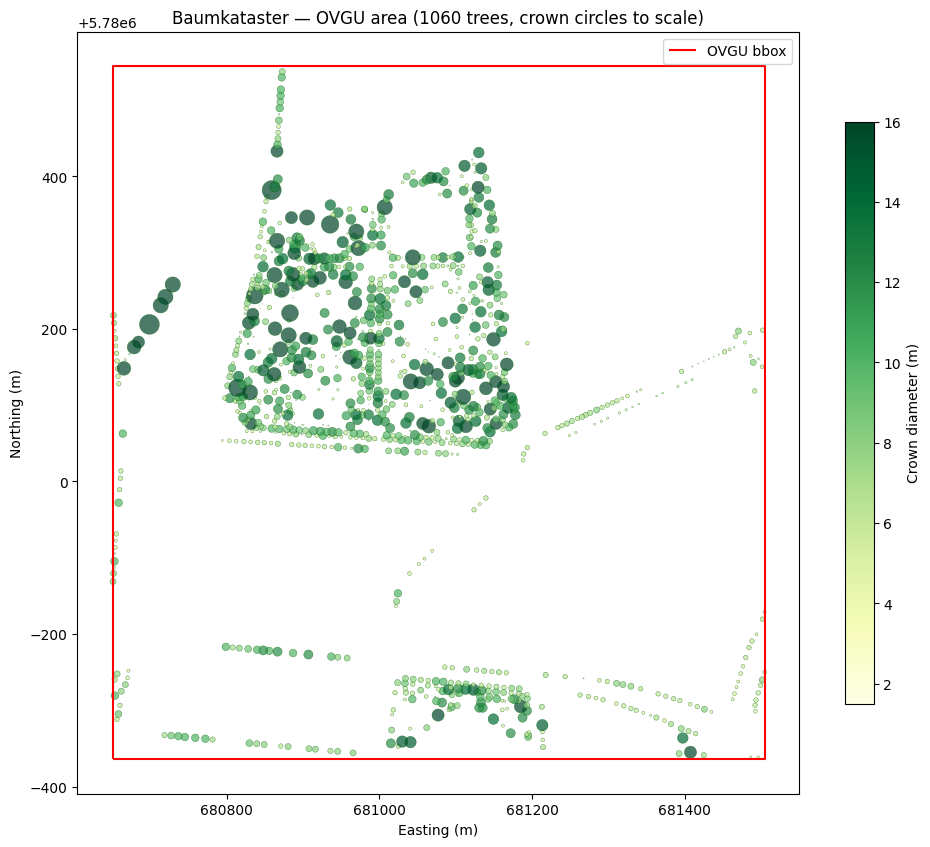

In [4]:
from pyproj import Transformer

_to_utm = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
ovgu = AREAS["ovgu_bbox"]
west_m, south_m = _to_utm.transform(ovgu["west"], ovgu["south"])
east_m, north_m = _to_utm.transform(ovgu["east"], ovgu["north"])
bbox_utm = gpd.GeoDataFrame(
    geometry=[box(west_m, south_m, east_m, north_m)],
    crs="EPSG:25832",
)

bk_ovgu = bk.clip(bbox_utm).copy()
bk_ovgu = bk_ovgu[bk_ovgu["Kronendurchmesser"] > 0].reset_index(drop=True)

print(f"Trees in OVGU bbox (with crown data): {len(bk_ovgu)}")
print(f"Crown diameter — mean: {bk_ovgu['Kronendurchmesser'].mean():.1f} m  "
      f"median: {bk_ovgu['Kronendurchmesser'].median():.1f} m  "
      f"max: {bk_ovgu['Kronendurchmesser'].max():.1f} m")

print("\n--- Species (OVGU) ---")
print(bk_ovgu["Gattung lang"].value_counts().head(15).to_string())

# Buffer each point by crown radius → actual circular footprint in map units
bk_crown = bk_ovgu.copy()
bk_crown["geometry"] = [
    g.buffer(d) for g, d in zip(bk_crown.geometry, bk_crown["Kronendurchmesser"] / 2)
]

norm = mcolors.Normalize(vmin=bk_ovgu["Kronendurchmesser"].quantile(0.05),
                         vmax=bk_ovgu["Kronendurchmesser"].quantile(0.95))
cmap = cm.YlGn
colors = cmap(norm(bk_crown["Kronendurchmesser"].values))

fig, ax = plt.subplots(figsize=(10, 10))
bk_crown.plot(ax=ax, color=colors, edgecolor="darkgreen", linewidth=0.3, alpha=0.7)
bbox_utm.boundary.plot(ax=ax, color="red", linewidth=1.5, label="OVGU bbox")

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Crown diameter (m)", shrink=0.6)

ax.set_title(f"Baumkataster — OVGU area ({len(bk_crown)} trees, crown circles to scale)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend()
plt.tight_layout()
plt.show()

## Majority species per tile (250 m grid)

Tile size: 250 m  |  Tiles: 16

  tile (0,3)  n=  14  majority: Populus (12, 86%)
  tile (1,3)  n=  20  majority: Acer (5, 25%)
  tile (2,3)  n=   0  majority: — (0, 0%)
  tile (3,3)  n=   0  majority: — (0, 0%)
  tile (0,2)  n= 135  majority: Prunus (28, 21%)
  tile (1,2)  n= 307  majority: Tilia (112, 36%)
  tile (2,2)  n=  26  majority: Acer (6, 23%)
  tile (3,2)  n=  18  majority: Amelanchier (6, 33%)
  tile (0,1)  n=  98  majority: Acer (31, 32%)
  tile (1,1)  n= 174  majority: Tilia (84, 48%)
  tile (2,1)  n=  57  majority: Sorbus (30, 53%)
  tile (3,1)  n=   3  majority: Sorbus (2, 67%)
  tile (0,0)  n=  33  majority: Platanus (16, 48%)
  tile (1,0)  n=  81  majority: Tilia (40, 49%)
  tile (2,0)  n=  65  majority: Tilia (42, 65%)
  tile (3,0)  n=  29  majority: Acer (19, 66%)


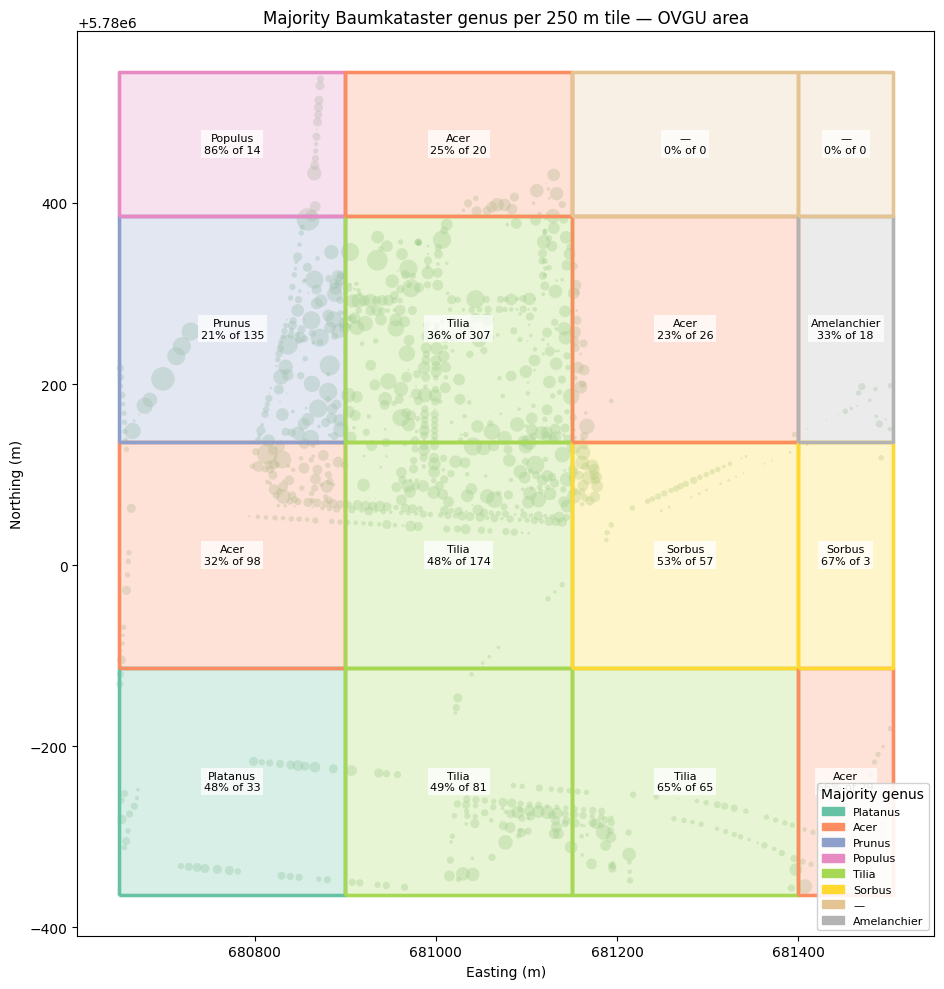

In [5]:
from src.data_preprocessing import tiles_for_area
from src.config import TILE_SIZE_M
import matplotlib.patches as mpatches

# Build UTM tile polygons and find majority genus in each
tiles = tiles_for_area(AREAS["ovgu_bbox"], TILE_SIZE_M)

records = []
for t in tiles:
    w_m, s_m = _to_utm.transform(t["west"], t["south"])
    e_m, n_m = _to_utm.transform(t["east"], t["north"])
    tile_poly = box(w_m, s_m, e_m, n_m)
    clipped = bk.clip(gpd.GeoDataFrame(geometry=[tile_poly], crs="EPSG:25832"))
    if len(clipped) == 0:
        majority, majority_n, majority_pct = "—", 0, 0.0
    else:
        # Extract genus (first word) so e.g. "Tilia cordata" and "Tilia platyphyllos" merge
        vc = clipped["Gattung lang"].str.split().str[0].value_counts()
        majority = vc.index[0]
        majority_n = int(vc.iloc[0])
        majority_pct = majority_n / len(clipped) * 100
    records.append({
        "ix": t["ix"], "iy": t["iy"],
        "n_trees": len(clipped),
        "majority_genus": majority,
        "majority_n": majority_n,
        "majority_pct": majority_pct,
        "geometry": tile_poly,
    })

tile_gdf = gpd.GeoDataFrame(records, crs="EPSG:25832")

# Print summary table
print(f"Tile size: {TILE_SIZE_M} m  |  Tiles: {len(tile_gdf)}\n")
for _, row in tile_gdf.sort_values(["iy", "ix"], ascending=[False, True]).iterrows():
    print(f"  tile ({row['ix']},{row['iy']})  n={row['n_trees']:>4}  "
          f"majority: {row['majority_genus']} ({row['majority_n']}, {row['majority_pct']:.0f}%)")

# Categorical color per majority genus
genus_list = tile_gdf["majority_genus"].unique().tolist()
palette = plt.cm.Set2.colors
genus_color = {g: palette[i % len(palette)] for i, g in enumerate(genus_list)}

fig, ax = plt.subplots(figsize=(10, 10))

# Crown circles dimmed to grey-green background
bk_crown.plot(ax=ax, color="#aacfaa", edgecolor="none", alpha=0.4)

# Tile fill + boundary colored by majority genus
for _, row in tile_gdf.iterrows():
    color = genus_color[row["majority_genus"]]
    gpd.GeoDataFrame([row], crs="EPSG:25832").plot(
        ax=ax, facecolor=color, edgecolor=color, linewidth=2.5, alpha=0.25
    )
    gpd.GeoDataFrame([row], crs="EPSG:25832").boundary.plot(
        ax=ax, color=color, linewidth=2.5
    )
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, f"{row['majority_genus']}\n{row['majority_pct']:.0f}% of {row['n_trees']}",
            ha="center", va="center", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2))

legend_patches = [
    mpatches.Patch(color=genus_color[g], label=g)
    for g in genus_list
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.9,
          title="Majority genus")

ax.set_title(f"Majority Baumkataster genus per {TILE_SIZE_M} m tile — OVGU area")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.tight_layout()
plt.show()

## Allometric calibration from Baumkataster

In [6]:
# Fit ln(H) = A + B·ln(CPA) on Baumkataster (citywide, valid measurements only)
cal = bk[["Baumhoehe", "Kronendurchmesser"]].copy()
cal = cal[(cal["Baumhoehe"] > 1) & (cal["Kronendurchmesser"] > 0.5)]  # drop zeros/tiny
cal["CPA_m2"] = math.pi * (cal["Kronendurchmesser"] / 2) ** 2
cal["ln_H"]   = np.log(cal["Baumhoehe"])
cal["ln_CPA"] = np.log(cal["CPA_m2"])

# OLS: ln(H) = A + B·ln(CPA)
X = np.column_stack([np.ones(len(cal)), cal["ln_CPA"].values])
B_hat, resid, _, _ = np.linalg.lstsq(X, cal["ln_H"].values, rcond=None)
A_urban, B_urban = B_hat

r2 = 1 - np.sum((cal["ln_H"] - (A_urban + B_urban * cal["ln_CPA"])) ** 2) / \
         np.sum((cal["ln_H"] - cal["ln_H"].mean()) ** 2)

print("=== Baumkataster-calibrated allometric model (citywide) ===")
print(f"  H = exp({A_urban:.3f} + {B_urban:.3f} · ln(CPA))   R² = {r2:.3f}   n = {len(cal):,}")
print()
print("=== Current config (src/config.py) ===")
print(f"  H = exp({ALLOMETRIC_A:.3f} + {ALLOMETRIC_B:.3f} · ln(CPA))")
print()

# Compare predictions at representative crown diameters
print(f"{'Crown D (m)':>12}  {'CPA (m²)':>10}  {'H_urban (m)':>12}  {'H_config (m)':>13}  {'Bk median H':>12}")
for cd in [4, 6, 8, 10, 12, 14]:
    cpa = math.pi * (cd / 2) ** 2
    h_urban = math.exp(A_urban + B_urban * math.log(cpa))
    h_config = math.exp(ALLOMETRIC_A + ALLOMETRIC_B * math.log(cpa))
    bk_med = bk[(bk["Kronendurchmesser"].between(cd - 0.5, cd + 0.5)) &
                (bk["Baumhoehe"] > 1)]["Baumhoehe"].median()
    print(f"{cd:>12}  {cpa:>10.1f}  {h_urban:>12.1f}  {h_config:>13.1f}  {bk_med:>12.1f}")

=== Baumkataster-calibrated allometric model (citywide) ===
  H = exp(1.317 + 0.318 · ln(CPA))   R² = 0.531   n = 84,081

=== Current config (src/config.py) ===
  H = exp(1.317 + 0.318 · ln(CPA))

 Crown D (m)    CPA (m²)   H_urban (m)   H_config (m)   Bk median H
           4        12.6           8.4            8.3           8.0
           6        28.3          10.8           10.8          10.0
           8        50.3          13.0           13.0          13.0
          10        78.5          15.0           14.9          15.0
          12       113.1          16.8           16.8          18.0
          14       153.9          18.5           18.5          20.0


## Pipeline validation — height estimates vs Baumkataster measurements

In [7]:
TILE_SIZE_VAL = 250   # change to 100 / 500 / 1000 to analyse a different tile size

merged_trees = gpd.read_file(
    OUTPUT_DIR / "segments" / f"{TILE_SIZE_VAL}m" / f"ovgu_bbox_tcd_segformer_trees_merged.fgb"
)
print(f"{len(merged_trees)} polygons  |  columns: {list(merged_trees.columns)}\n")
print(f"height_source breakdown:\n{merged_trees['height_source'].value_counts().to_string()}\n")
merged_trees[["tree_id", "height_m", "allometric_height_m", "height_source",
              "species", "crown_area_m2", "bk_match_dist_m"]].head(10)

942 polygons  |  columns: ['tree_id', 'height_m', 'allometric_height_m', 'crown_radius_m', 'crown_area_m2', 'vegetation_model', 'species', 'height_source', 'is_deciduous', 'trunk_circumference_cm', 'planting_year', 'bk_match_dist_m', 'geometry']

height_source breakdown:
height_source
allometric    668
measured      274



,tree_id,height_m,allometric_height_m,height_source,species,crown_area_m2,bk_match_dist_m
0,41,8.000000,8.530228,measured,"Tilia cordata, Winterlinde",13.455953,0.5204198973191211
1,42,5.000000,4.988497,measured,"Tilia cordata, Winterlinde",2.490225,0.8630782728577719
2,40,18.000000,17.972378,measured,"Populus simonii, Birkenpappel",140.173461,0.9990817276521374
3,39,11.675749,11.675749,allometric,None,36.108264,None
4,38,8.000000,12.487390,measured,"Tilia cordata, Winterlinde",44.605611,0.585974173660797
5,37,8.000000,10.965649,measured,"Tilia cordata, Winterlinde",29.642417,1.4039955230949044
6,28,27.809760,27.809760,allometric,None,553.179482,None
7,35,8.000000,11.534668,measured,"Tilia cordata, Winterlinde",34.753931,1.0808413419117062
8,33,7.000000,9.138571,measured,"Tilia cordata, Winterlinde",16.710721,0.8205961392047085
9,25,21.760810,21.760810,allometric,None,255.794177,None


Allometric vs BK measured height  (n=274)
  Bias  = +4.82 m   (+ = over-estimate)
  MAE   = 6.08 m
  RMSE  = 10.07 m
  R²    = -2.295


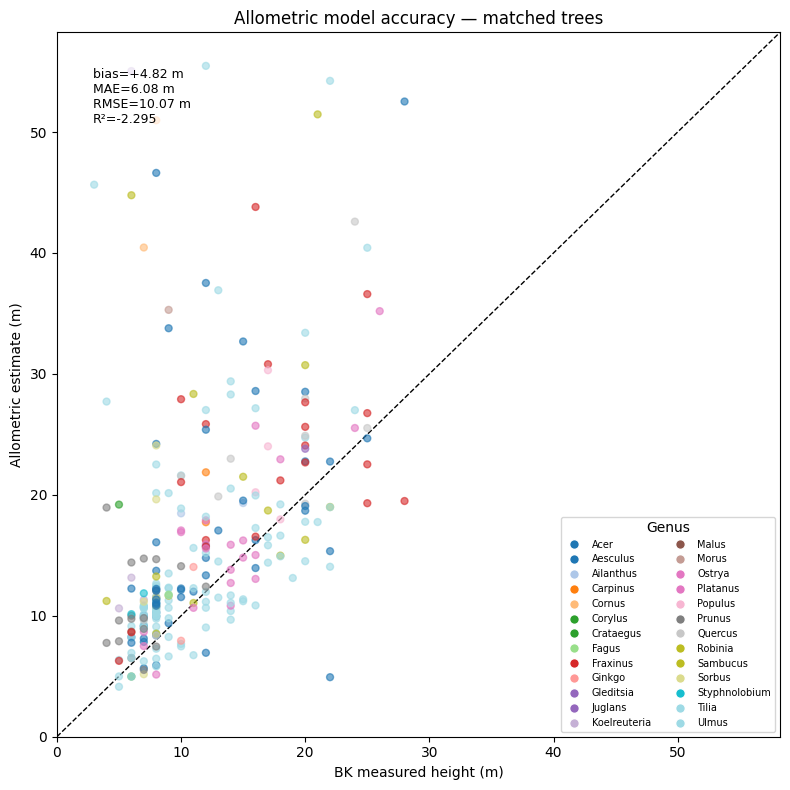

In [8]:
# Overall allometric vs BK measured height accuracy
matched_h = merged_trees[merged_trees["height_source"] == "measured"].copy()
matched_h["err"] = matched_h["allometric_height_m"] - matched_h["height_m"]

bias = matched_h["err"].mean()
mae  = matched_h["err"].abs().mean()
rmse = (matched_h["err"] ** 2).mean() ** 0.5
ss_res = ((matched_h["allometric_height_m"] - matched_h["height_m"]) ** 2).sum()
ss_tot = ((matched_h["height_m"] - matched_h["height_m"].mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot

print(f"Allometric vs BK measured height  (n={len(matched_h)})")
print(f"  Bias  = {bias:+.2f} m   (+ = over-estimate)")
print(f"  MAE   = {mae:.2f} m")
print(f"  RMSE  = {rmse:.2f} m")
print(f"  R²    = {r2:.3f}")

# Scatter: allometric vs measured, coloured by genus
genus_labels = matched_h["species"].str.split().str[0].fillna("Unknown")
unique_genera = sorted(genus_labels.unique())
cmap_g = plt.cm.tab20
g_color = {g: cmap_g(i / max(len(unique_genera) - 1, 1)) for i, g in enumerate(unique_genera)}
colors_pts = [g_color[g] for g in genus_labels]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(matched_h["height_m"], matched_h["allometric_height_m"],
           c=colors_pts, alpha=0.6, s=25, zorder=3)
lim = [0, max(matched_h[["height_m", "allometric_height_m"]].max()) * 1.05]
ax.plot(lim, lim, "k--", linewidth=1, label="1:1 line")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("BK measured height (m)")
ax.set_ylabel("Allometric estimate (m)")
ax.set_title("Allometric model accuracy — matched trees")
ax.text(0.05, 0.95,
        f"bias={bias:+.2f} m\nMAE={mae:.2f} m\nRMSE={rmse:.2f} m\nR²={r2:.3f}",
        transform=ax.transAxes, va="top", fontsize=9,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", pad=4))
handles = [plt.Line2D([0], [0], marker="o", color="w",
                      markerfacecolor=g_color[g], markersize=7, label=g)
           for g in unique_genera]
ax.legend(handles=handles, title="Genus", fontsize=7, loc="lower right", ncol=2)
plt.tight_layout()
plt.show()

Per-tile allometric height error  (250 m grid)

    tile     n   bias (m)   MAE (m)
------------------------------------
  (0,3)     4      +6.32      6.32
  (1,3)     4      +4.26      4.62
  (2,3)     0       +nan       nan
  (3,3)     0       +nan       nan
  (0,2)    27      +7.41      7.74
  (1,2)    52      +7.21      8.69
  (2,2)     8      +5.90      6.27
  (3,2)     7      +3.43      3.68
  (0,1)    19      +7.65      8.35
  (1,1)    33      +2.31      5.83
  (2,1)     8      +5.90     10.63
  (3,1)     1      +7.22      7.22
  (0,0)    25      +0.40      2.76
  (1,0)    26      +5.34      5.69
  (2,0)    36      +4.12      4.35
  (3,0)    24      +2.51      2.80


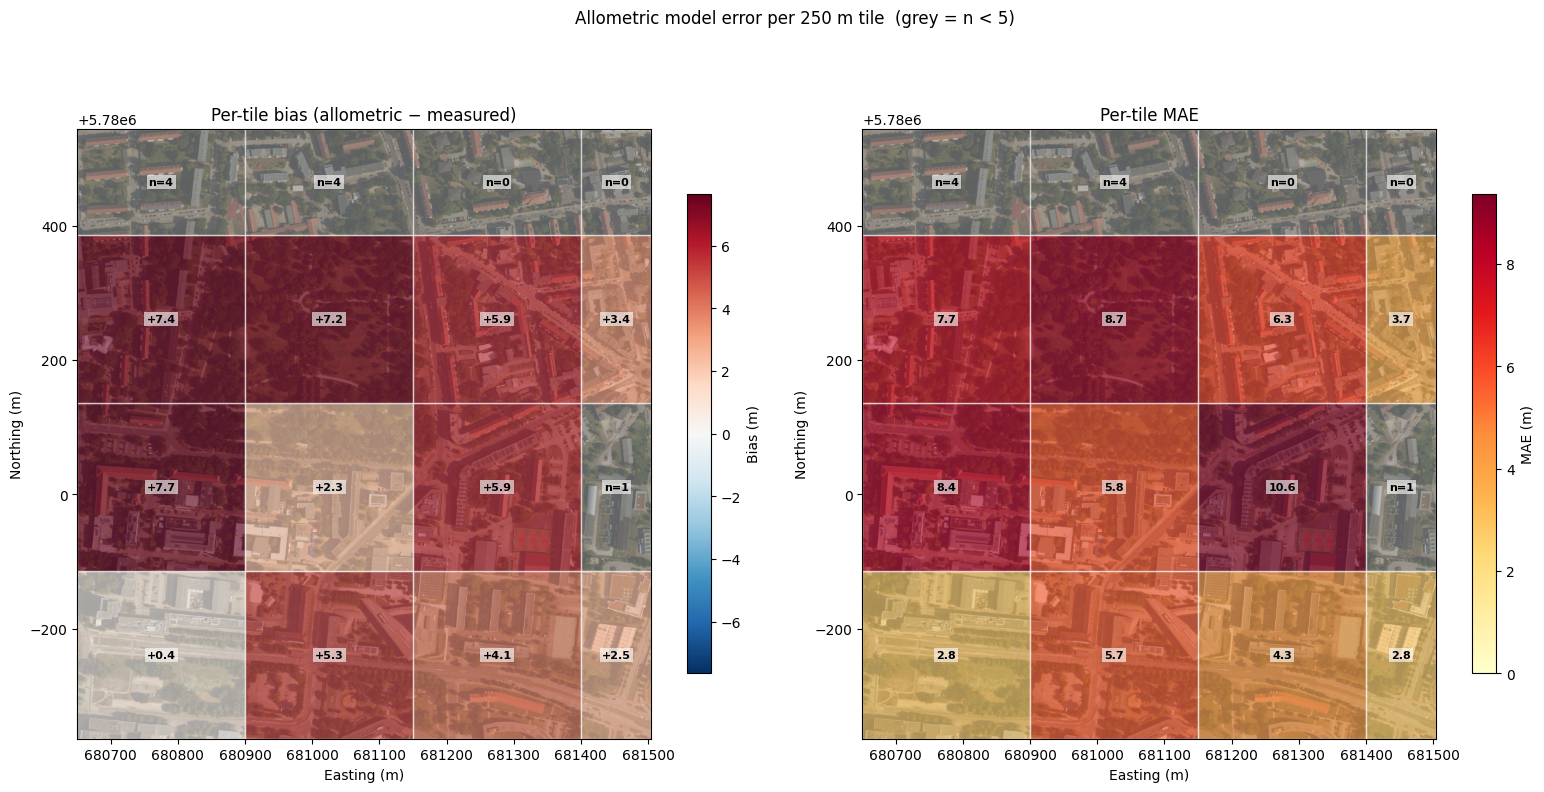

In [9]:
from PIL import Image as PILImage

# Per-tile allometric height bias and MAE  (uses TILE_SIZE_VAL from the load cell above)
full_img_h = np.array(PILImage.open(OUTPUT_DIR / "ovgu_bbox" / "ovgu_bbox_full.png").convert("RGB"))
extent_h = [west_m, east_m, south_m, north_m]

tiles_h = tiles_for_area(AREAS["ovgu_bbox"], TILE_SIZE_VAL)
N_MIN_H = 5   # tiles with fewer matched trees shown in grey

tile_h_records = []
for t in tiles_h:
    w_m2, s_m2 = _to_utm.transform(t["west"], t["south"])
    e_m2, n_m2 = _to_utm.transform(t["east"], t["north"])
    tile_poly = box(w_m2, s_m2, e_m2, n_m2)
    clip = matched_h[matched_h.geometry.centroid.within(tile_poly)]
    if len(clip) == 0:
        bias_t, mae_t, n_t = None, None, 0
    else:
        err_t = clip["allometric_height_m"] - clip["height_m"]
        bias_t, mae_t, n_t = float(err_t.mean()), float(err_t.abs().mean()), len(clip)
    tile_h_records.append({
        "ix": t["ix"], "iy": t["iy"],
        "n": n_t, "bias": bias_t, "mae": mae_t,
        "geometry": tile_poly,
    })

tile_h = gpd.GeoDataFrame(tile_h_records, crs="EPSG:25832")

# Print table
print(f"Per-tile allometric height error  ({TILE_SIZE_VAL} m grid)\n")
print(f"{'tile':>8}  {'n':>4}  {'bias (m)':>9}  {'MAE (m)':>8}")
print("-" * 36)
for _, row in tile_h.sort_values(["iy", "ix"], ascending=[False, True]).iterrows():
    b = f"{row['bias']:+.2f}" if row["bias"] is not None else "  —  "
    m = f"{row['mae']:.2f}"  if row["mae"]  is not None else "  —  "
    print(f"  ({row['ix']:.0f},{row['iy']:.0f})  {row['n']:>4}  {b:>9}  {m:>8}")

# --- Figures ---
bias_vals = tile_h["bias"].dropna()
vlim = max(abs(bias_vals.min()), abs(bias_vals.max()), 1.0)
norm_bias = mcolors.TwoSlopeNorm(vmin=-vlim, vcenter=0, vmax=vlim)
cmap_bias = plt.cm.RdBu_r

mae_vals = tile_h["mae"].dropna()
norm_mae = mcolors.Normalize(vmin=0, vmax=mae_vals.quantile(0.95))
cmap_mae = plt.cm.YlOrRd

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, col, norm, cmap, title, label in [
    (axes[0], "bias", norm_bias, cmap_bias,
     "Per-tile bias (allometric − measured)", "Bias (m)"),
    (axes[1], "mae",  norm_mae,  cmap_mae,
     "Per-tile MAE",                          "MAE (m)"),
]:
    ax.imshow(full_img_h, extent=extent_h, origin="upper", aspect="equal")
    for _, row in tile_h.iterrows():
        gdf_t = gpd.GeoDataFrame([row], crs="EPSG:25832")
        if row[col] is None or row["n"] < N_MIN_H:
            gdf_t.plot(ax=ax, facecolor="#888888", edgecolor="white",
                       linewidth=1, alpha=0.5, zorder=2)
            lbl = f"n={row['n']:.0f}"
        else:
            color = cmap(norm(row[col]))
            gdf_t.plot(ax=ax, facecolor=color, edgecolor="white",
                       linewidth=1, alpha=0.6, zorder=2)
            lbl = f"{row[col]:+.1f}" if col == "bias" else f"{row[col]:.1f}"
        cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
        ax.text(cx, cy, lbl, ha="center", va="center", fontsize=8, fontweight="bold",
                color="black",
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5),
                zorder=3)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label=label, shrink=0.65)
    ax.set_xlim(west_m, east_m); ax.set_ylim(south_m, north_m)
    ax.set_title(title)
    ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")

plt.suptitle(f"Allometric model error per {TILE_SIZE_VAL} m tile  (grey = n < {N_MIN_H})", y=1.01)
plt.tight_layout()
plt.show()

## Crown area validation — per-tree and tile-wise

Two complementary checks:
1. **Per-tree**: for each matched pipeline polygon, compare `crown_area_m2` against `π·(Kronendurchmesser/2)²`
2. **Tile-wise**: aggregate total crown area per tile — avoids per-tree matching noise and reveals systematic over/under-segmentation

> **Caveat**: BK only registers street and public trees — private gardens and some parks are absent.
> Ratio pipeline/BK > 1 is expected in park or campus tiles. Tiles with `bk_count ≥ 10` give the most reliable signal.

    tile   n_pipe    pipe_m²    n_bk     bk_m²   ratio   flag
--------------------------------------------------------------
  (0,3)       43       7159      14       986    7.26       
  (1,3)       40      10125      20      1525    6.64       
  (2,3)       65       8211       0         0     nan    LOW
  (3,3)       27       2221       0         0     nan    LOW
  (0,2)       65      18304     135     12945    1.41       
  (1,2)       69      28186     307     22673    1.24       
  (2,2)       55       9716      26      1690    5.75       
  (3,2)       23       1585      18       278    5.70       
  (0,1)       82      13797      98      4919    2.80       
  (1,1)       93      16580     174     11849    1.40       
  (2,1)       70       8667      57      3171    2.73       
  (3,1)       24       2238       3        42   52.76    LOW
  (0,0)       57      10098      33      1911    5.28       
  (1,0)       82      11142      81      4907    2.27       
  (2,0)      105     

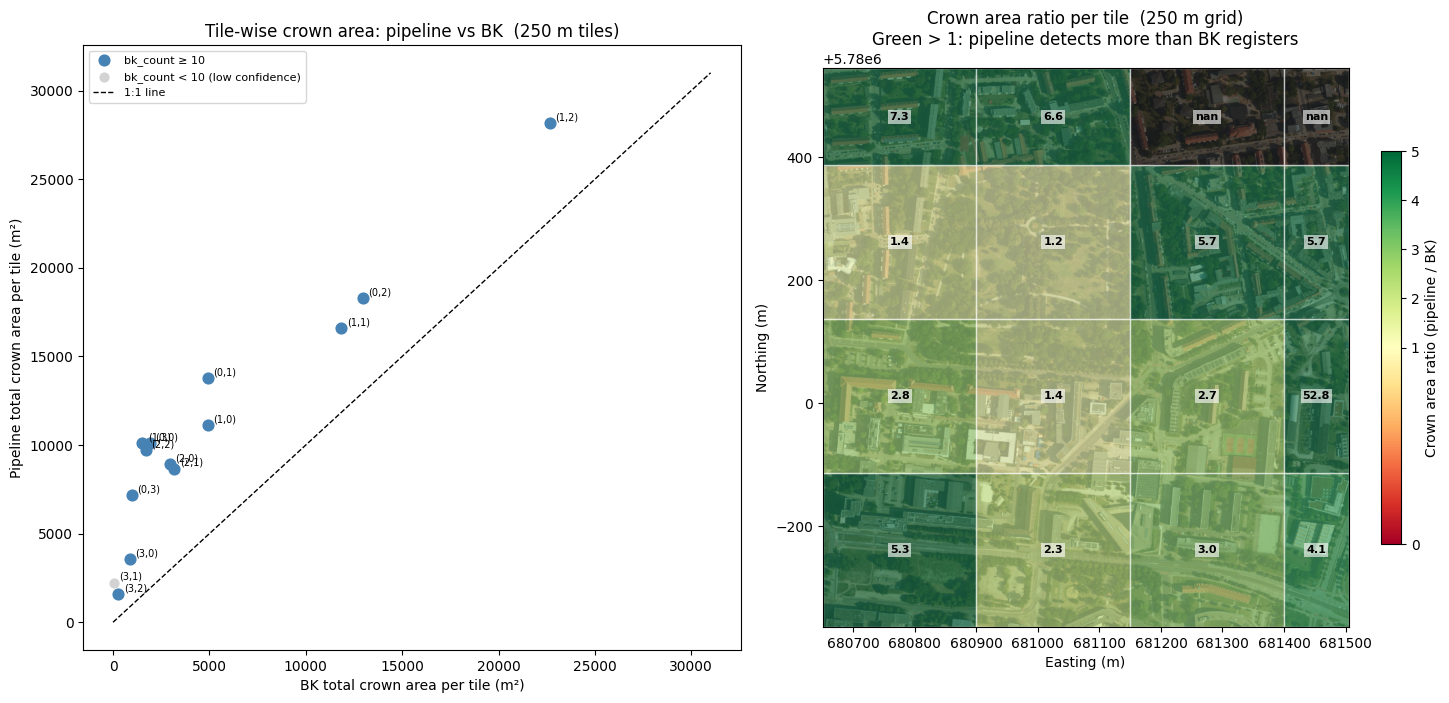

In [11]:
from PIL import Image as PILImage

# Load orthophoto for background
full_img = np.array(PILImage.open(OUTPUT_DIR / "ovgu_bbox" / "ovgu_bbox_full.png").convert("RGB"))
extent = [west_m, east_m, south_m, north_m]

tiles = tiles_for_area(AREAS["ovgu_bbox"], TILE_SIZE_VAL)

BK_MIN_COUNT = 10   # tiles with fewer BK trees are flagged as low-confidence

tile_records = []
for t in tiles:
    w_m, s_m = _to_utm.transform(t["west"], t["south"])
    e_m, n_m = _to_utm.transform(t["east"], t["north"])
    tile_poly = box(w_m, s_m, e_m, n_m)
    tile_frame = gpd.GeoDataFrame(geometry=[tile_poly], crs="EPSG:25832")

    # Pipeline: polygons whose centroid is inside this tile
    pipe_clip  = tree_gdf[tree_gdf.geometry.centroid.within(tile_poly)]
    pipe_area  = float(pipe_clip["crown_area_m2"].sum())
    pipe_count = len(pipe_clip)

    # BK: registered trees inside tile (reset index to avoid duplicate-label issues)
    bk_clip  = bk.clip(tile_frame).reset_index(drop=True)
    bk_valid = bk_clip[bk_clip["Kronendurchmesser"] > 0]
    bk_area  = float(np.pi * ((bk_valid["Kronendurchmesser"] / 2) ** 2).sum())
    bk_count = len(bk_valid)

    ratio = pipe_area / bk_area if bk_area > 0 else None
    tile_records.append({
        "ix": t["ix"], "iy": t["iy"],
        "pipe_count": pipe_count, "pipe_area_m2": pipe_area,
        "bk_count": bk_count, "bk_area_m2": bk_area,
        "ratio": ratio,
        "geometry": tile_poly,
    })

tile_val = gpd.GeoDataFrame(tile_records, crs="EPSG:25832")

# Print table
print(f"{'tile':>8}  {'n_pipe':>7}  {'pipe_m²':>9}  {'n_bk':>6}  {'bk_m²':>8}  {'ratio':>6}  {'flag':>5}")
print("-" * 62)
for _, row in tile_val.sort_values(["iy", "ix"], ascending=[False, True]).iterrows():
    flag = "LOW" if row["bk_count"] < BK_MIN_COUNT else ""
    ratio_str = f"{row['ratio']:.2f}" if row["ratio"] is not None else "  —  "
    print(f"  ({row['ix']:.0f},{row['iy']:.0f})  {row['pipe_count']:>7}  "
          f"{row['pipe_area_m2']:>9.0f}  {row['bk_count']:>6}  "
          f"{row['bk_area_m2']:>8.0f}  {ratio_str:>6}  {flag:>5}")

# --- Figure 1: scatter BK vs pipeline total crown area per tile ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ax = axes[0]
with_bk  = tile_val[tile_val["ratio"].notna()]
conf     = with_bk[with_bk["bk_count"] >= BK_MIN_COUNT]
low_conf = with_bk[with_bk["bk_count"] < BK_MIN_COUNT]

ax.scatter(conf["bk_area_m2"],     conf["pipe_area_m2"],     s=60, color="steelblue",
           label=f"bk_count ≥ {BK_MIN_COUNT}", zorder=3)
ax.scatter(low_conf["bk_area_m2"], low_conf["pipe_area_m2"], s=40, color="lightgrey",
           label=f"bk_count < {BK_MIN_COUNT} (low confidence)", zorder=2)
for _, row in with_bk.iterrows():
    ax.annotate(f"({row['ix']:.0f},{row['iy']:.0f})",
                (row["bk_area_m2"], row["pipe_area_m2"]),
                fontsize=7, textcoords="offset points", xytext=(4, 2))
lim_max = max(with_bk[["bk_area_m2", "pipe_area_m2"]].max()) * 1.1
ax.plot([0, lim_max], [0, lim_max], "k--", linewidth=1, label="1:1 line")
ax.set_xlabel("BK total crown area per tile (m²)")
ax.set_ylabel("Pipeline total crown area per tile (m²)")
ax.set_title(f"Tile-wise crown area: pipeline vs BK  ({TILE_SIZE_VAL} m tiles)")
ax.legend(fontsize=8)

# --- Figure 2: choropleth of ratio on orthophoto ---
ax = axes[1]
ax.imshow(full_img, extent=extent, origin="upper", aspect="equal")

ratio_vals = tile_val["ratio"].dropna()
vmax = min(ratio_vals.quantile(0.95), 5.0)
norm_div = mcolors.TwoSlopeNorm(vmin=0, vcenter=1.0, vmax=vmax)
cmap_div = plt.cm.RdYlGn

for _, row in tile_val.iterrows():
    gdf_tile = gpd.GeoDataFrame([row], crs="EPSG:25832")
    if row["ratio"] is None:
        gdf_tile.plot(ax=ax, facecolor="#888888", edgecolor="white", linewidth=1,
                      alpha=0.5, zorder=2)
    else:
        color = cmap_div(norm_div(row["ratio"]))
        gdf_tile.plot(ax=ax, facecolor=color, edgecolor="white", linewidth=1,
                      alpha=0.55, zorder=2)
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ratio_label = f"{row['ratio']:.1f}" if row["ratio"] is not None else "—"
    ax.text(cx, cy, ratio_label, ha="center", va="center", fontsize=8, fontweight="bold",
            color="black", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.5),
            zorder=3)

sm = plt.cm.ScalarMappable(cmap=cmap_div, norm=norm_div)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Crown area ratio (pipeline / BK)", shrink=0.65)
ax.set_xlim(west_m, east_m); ax.set_ylim(south_m, north_m)
ax.set_title(f"Crown area ratio per tile  ({TILE_SIZE_VAL} m grid)\n"
             f"Green > 1: pipeline detects more than BK registers")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")

plt.tight_layout()
plt.show()

## Per-genus allometric profiles

Fit `ln(H) = A + B·ln(CPA)` separately for each genus with at least 200 valid trees.
Copy the printed dict into `ALLOMETRIC_PROFILES` in `src/config.py`.

In [12]:
N_MIN = 200   # minimum trees per genus to fit a profile

cal_all = bk[["Gattung lang", "Baumhoehe", "Kronendurchmesser"]].copy()
cal_all = cal_all[(cal_all["Baumhoehe"] > 1) & (cal_all["Kronendurchmesser"] > 0.5)]
cal_all["genus"]  = cal_all["Gattung lang"].str.split(",").str[0]
cal_all["CPA_m2"] = np.pi * (cal_all["Kronendurchmesser"] / 2) ** 2
cal_all["ln_H"]   = np.log(cal_all["Baumhoehe"])
cal_all["ln_CPA"] = np.log(cal_all["CPA_m2"])

profiles = {}
for genus, grp in cal_all.groupby("genus"):
    if len(grp) < N_MIN:
        continue
    X = np.column_stack([np.ones(len(grp)), grp["ln_CPA"].values])
    B_hat, *_ = np.linalg.lstsq(X, grp["ln_H"].values, rcond=None)
    A_g, B_g = float(B_hat[0]), float(B_hat[1])
    pred = A_g + B_g * grp["ln_CPA"].values
    r2 = 1 - np.sum((grp["ln_H"].values - pred) ** 2) / \
              np.sum((grp["ln_H"].values - grp["ln_H"].mean()) ** 2)
    profiles[genus] = (round(A_g, 4), round(B_g, 4), round(r2, 3), len(grp))

# Print table
print(f"{'Genus':<18} {'n':>6}  {'A':>7}  {'B':>7}  {'R²':>6}")
print("-" * 52)
for genus, (A_g, B_g, r2, n) in sorted(profiles.items(), key=lambda x: -x[1][3]):
    print(f"{genus:<18} {n:>6}  {A_g:>7.4f}  {B_g:>7.4f}  {r2:>6.3f}")

# Print paste-ready dict for src/config.py
print("\n# ── paste into ALLOMETRIC_PROFILES in src/config.py ──")
print("ALLOMETRIC_PROFILES: dict[str, tuple[float, float]] = {")
for genus, (A_g, B_g, r2, n) in sorted(profiles.items(), key=lambda x: -x[1][3]):
    print(f'    "{genus}": ({A_g}, {B_g}),  # R²={r2}, n={n}')
print("}")

Genus                   n        A        B      R²
----------------------------------------------------
Tilia cordata       10435   1.0799   0.3864   0.665
Acer platanoides     8119   1.5002   0.2716   0.470
Robinia pseudoacacia   5779   1.8419   0.2185   0.310
Fraxinus excelsior   5607   1.4301   0.3106   0.500
Quercus robur        4858   1.3798   0.3120   0.572
Acer pseudoplatanus   4031   1.5826   0.2594   0.419
Acer campestre       3924   1.4289   0.2706   0.483
Aesculus hippocastanum   2479   1.3895   0.3096   0.569
Carpinus betulus     2196   1.3151   0.3183   0.592
Prunus avium         1750   1.3153   0.2522   0.428
Acer negundo         1736   1.5969   0.2079   0.327
Platanus acerifolia   1510   1.1471   0.3503   0.652
Pyrus communis       1225   1.1895   0.2476   0.558
Tilia platyphyllos   1209   1.5648   0.2706   0.460
Populus canadensis Hybride   1109   2.2410   0.2012   0.290
Tilia cordata 'Greenspire'    863   1.4216   0.2484   0.687
Ulmus laevis          849   1.6273   0.

## Per-genus crown radius thresholds (watershed)

Median `Kronendurchmesser / 2` per genus — used as the species-aware watershed split
threshold in `vectorize_trees`. Copy the printed dict into `CROWN_RADIUS_BY_GENUS`
in `src/config.py`.

In [13]:
cr_data = bk[["Gattung lang", "Kronendurchmesser"]].copy()
cr_data = cr_data[cr_data["Kronendurchmesser"] > 0.5]
cr_data["genus"]     = cr_data["Gattung lang"].str.split(",").str[0]
cr_data["crown_r_m"] = cr_data["Kronendurchmesser"] / 2

# Median crown radius and 95th-percentile per genus (n >= N_MIN)
cr_stats = (
    cr_data.groupby("genus")["crown_r_m"]
    .agg(n="count", median="median", p95=lambda x: x.quantile(0.95))
    .query(f"n >= {N_MIN}")
    .sort_values("n", ascending=False)
)

print(f"{'Genus':<18} {'n':>6}  {'median r (m)':>13}  {'p95 r (m)':>10}")
print("-" * 54)
for genus, row in cr_stats.iterrows():
    print(f"{genus:<18} {row['n']:>6}  {row['median']:>13.2f}  {row['p95']:>10.2f}")

# Print paste-ready dict for src/config.py
# Use 95th-percentile as threshold so most single trees still pass unsplit.
print("\n# ── paste into CROWN_RADIUS_BY_GENUS in src/config.py ──")
print("CROWN_RADIUS_BY_GENUS: dict[str, float] = {")
for genus, row in cr_stats.iterrows():
    print(f'    "{genus}": {round(row["p95"], 1)},  # median={row["median"]:.1f} m, n={row["n"]}')
print("}")

Genus                   n   median r (m)   p95 r (m)
------------------------------------------------------
Tilia cordata      10444.0           3.50        6.50
Acer platanoides   8120.0           3.50        6.50
Robinia pseudoacacia 5781.0           3.50        6.50
Fraxinus excelsior 5609.0           3.50        7.50
Quercus robur      4923.0           4.00        9.00
Acer pseudoplatanus 4033.0           3.50        7.00
Acer campestre     3925.0           3.00        6.00
Aesculus hippocastanum 2483.0           3.50        7.00
Carpinus betulus   2197.0           3.00        6.50
Prunus avium       1752.0           2.50        5.00
Acer negundo       1736.0           4.00        7.50
Platanus acerifolia 1510.0           4.00        8.50
Pyrus communis     1225.0           2.00        5.00
Tilia platyphyllos 1209.0           4.00        7.00
Populus canadensis Hybride 1109.0           4.00        8.80
Tilia cordata 'Greenspire'  863.0           3.00        5.00
Ulmus laevis       